In [176]:
#import keras
import tensorflow as tf
from tensorflow import keras
from IPython.display import Image
import matplotlib.pyplot as plt
#from keras import layers
#from keras import ops
from tensorflow.keras import layers
import os


In [189]:

train_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="training",
    seed=42,
    color_mode="grayscale",
    image_size=(128,128),
    batch_size=32
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    "rps-cv-images",
    validation_split=0.30,
    subset="validation",
    seed=42,
    color_mode="grayscale",
    image_size=(128,128),
    batch_size=32
)

temp_size = len(temp_ds)

val_size = temp_size // 2

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)


Found 2188 files belonging to 3 classes.
Using 1532 files for training.
Found 2188 files belonging to 3 classes.
Using 656 files for validation.


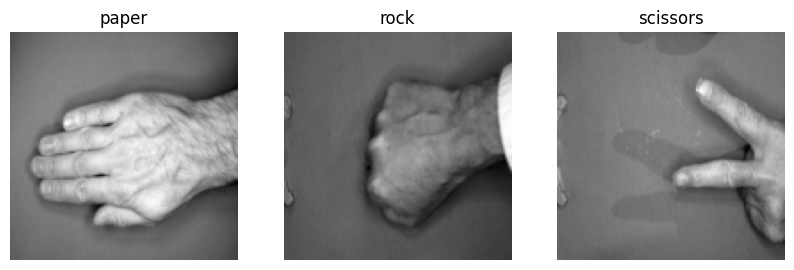

In [190]:
# Display one image per class
shown_classes = set()
plt.figure(figsize=(10, 4))
for images, labels in train_ds.unbatch():
    label = labels.numpy()
    if label not in shown_classes:
        plt.subplot(1, len(class_names), len(shown_classes) + 1)
        plt.imshow(images.numpy().squeeze(), cmap="gray")  
        plt.title(class_names[label])
        plt.axis("off")
        shown_classes.add(label)
    if len(shown_classes) == len(class_names):
        break
plt.show()

In [191]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
   
])

In [ ]:
model_1 = keras.Sequential(
    [
    data_augmentation,
    layers.Resizing(96, 96),        
   layers.Conv2D(24, (3, 3), activation="relu", input_shape=(96, 96, 1)),
   layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(3,activation='softmax')

    ]
)

In [193]:
model_1.summary()


Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_51 (Sequential)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_126 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_100               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_27 (Flatten)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_62 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_63 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [194]:
model_1.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [195]:
model_1.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.3341 - loss: 204.5358 - val_accuracy: 0.3719 - val_loss: 12.4670
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5030 - loss: 7.4049 - val_accuracy: 0.5844 - val_loss: 3.1795
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7107 - loss: 1.6094 - val_accuracy: 0.7563 - val_loss: 1.2285
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7324 - loss: 1.4625 - val_accuracy: 0.6500 - val_loss: 2.3360
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6956 - loss: 1.4410 - val_accuracy: 0.7812 - val_loss: 1.0494
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.7510 - loss: 0.9766 - val_accuracy: 0.8156 - val_loss: 0.7384
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8093 - loss: 0.6545 - val_accuracy: 0.8156 - val_loss: 0.7764
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8149 - loss: 0.5387 - val_accuracy: 0.8562 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Predicted label: scissors
Actual label: scissors


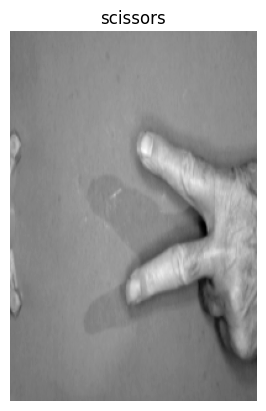

In [184]:
for images, labels in test_ds.take(1):
    
    image = images[0].numpy()
    label = labels[0].numpy()
    prediction = model_1.predict(image[None, ...])

    print(f"Predicted label: {class_names[prediction.argmax()]}")
    print(f"Actual label: {class_names[label]}")

    plt.imshow(image.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis("off")
    plt.show()

In [196]:
model_2 = keras.Sequential(
    [
        data_augmentation,
   layers.Conv2D(24, (3, 3), activation="relu", input_shape=(128, 128, 1)),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(48, (3, 3), activation="relu"),
   layers.MaxPooling2D((2, 2)),
   layers.Conv2D(96, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(84, activation="relu"),

    layers.Dense(3,activation='softmax')

    ]
)

In [197]:
model_2.summary()


Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_51 (Sequential)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_127 (Conv2D)             │ (None, 126, 126, 24)   │           240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_101               │ (None, 63, 63, 24)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_128 (Conv2D)             │ (None, 61, 61, 48)     │        10,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_102               │ (None, 30, 30, 48)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_129 (Conv2D)             │ (None, 28, 28, 96)     │        41,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_103               │ (None, 14, 14, 96)     │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 18816)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 128)            │     2,408,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_65 (Dense)                │ (None, 84)             │        10,836 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_66 (Dense)                │ (None, 3)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,471,891 (9.43 MB)

 Trainable params: 2,471,891 (9.43 MB)

 Non-trainable params: 0 (0.00 B)

In [198]:
model_2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [199]:
model_2.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - accuracy: 0.4010 - loss: 18.1120 - val_accuracy: 0.7250 - val_loss: 0.7281
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.7215 - loss: 0.6704 - val_accuracy: 0.7688 - val_loss: 0.5422
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.7664 - loss: 0.5467 - val_accuracy: 0.8750 - val_loss: 0.3605
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 76ms/step - accuracy: 0.8025 - loss: 0.4607 - val_accuracy: 0.9312 - val_loss: 0.2166
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 84ms/step - accuracy: 0.8403 - loss: 0.3970 - val_accuracy: 0.7156 - val_loss: 0.8014
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.7316 - loss: 0.8269 - val_accuracy: 0.7594 - val_loss: 0.5743
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - accuracy: 0.8501 - loss: 0.4002 - val_accuracy: 0.9187 - val_loss: 0.2860
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.8720 - loss: 0.3420 - val_accuracy: 0.9000 - 

In [ ]:

model_3 = keras.Sequential([
    layers.Resizing(96, 96),
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(128, (1, 1), activation="relu"),  # 1x1 convolution
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.BatchNormalization(),
    layers.Conv2D(256, (1, 1), activation="relu"),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(3, activation="softmax")  # 3 classes
])

In [213]:
model_3.summary()


Model: "sequential_58"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_151 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_152 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_118               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_153 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_154 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_119               │ ?                      │             0 │
│ (MaxPooling2D)                  │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_155 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_156 (Conv2D)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_15     │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_67 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_68 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [214]:
model_3.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model_3.fit(train_ds, validation_data=val_ds, epochs=10)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 464ms/step - accuracy: 0.6204 - loss: 0.8225 - val_accuracy: 0.3562 - val_loss: 8.4449
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 22s 457ms/step - accuracy: 0.9519 - loss: 0.1624 - val_accuracy: 0.5250 - val_loss: 1.1581
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 440ms/step - accuracy: 0.9692 - loss: 0.1311 - val_accuracy: 0.3656 - val_loss: 3.6090
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 437ms/step - accuracy: 0.9832 - loss: 0.0516 - val_accuracy: 0.9469 - val_loss: 0.1831
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 447ms/step - accuracy: 0.9851 - loss: 0.0535 - val_accuracy: 0.3500 - val_loss: 10.6198
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 442ms/step - accuracy: 0.9841 - loss: 0.0504 - val_accuracy: 0.5375 - val_loss: 1.8864
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 440ms/step - accuracy: 0.9833 - loss: 0.0494 - val_accuracy: 0.3469 - val_loss: 12.2855
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 21s 446ms/step - accuracy: 0.9925 - loss: 0.0249 - val_ac